# Obtaining Data from USDA Local Food Directory

In [2]:
import requests
import geopandas as gpd
from io import BytesIO 
import urllib.parse
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Obtaining shapefiles for target Texas counties 
# 1. Define the endpoint
base_url = "https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/State_County/MapServer/1/query"

# 2. Build parameters (Note the addition of returnGeometry)
query_params = {
    "where": "BASENAME IN ('Dallas', 'Tarrant', 'Harris', 'Travis', 'Bexar') AND STATE='48'", 
    "outFields": "*",
    "returnGeometry": "true",  # CRITICAL: Forces the API to include the polygons
    "f": "geojson"
}

encoded_params = urllib.parse.urlencode(query_params)
request_url = f"{base_url}?{encoded_params}"

# 3. Fetch the data
response = requests.get(request_url)
response.raise_for_status()
data = response.json()

# 4. Ensure we actually got features back
if 'features' not in data or len(data['features']) == 0:
    raise ValueError("The API returned an empty dataset. Check your 'where' clause.")

# 5. Load into GeoPandas
target_counties = gpd.GeoDataFrame.from_features(data["features"])

# 6. CRITICAL FIX: Explicitly set the active geometry column
# We check to ensure the column exists first so it doesn't throw a confusing error
if 'geometry' in target_counties.columns:
    target_counties = target_counties.set_geometry('geometry')
else:
    raise KeyError("The API did not return a 'geometry' column. The API endpoint may not support GeoJSON export natively.")

# 7. Set the coordinate reference system
target_counties.set_crs(epsg=4326, inplace=True)

# Save it to disk
target_counties.to_file('texas_counties.geojson', driver='GeoJSON')
print("Successfully downloaded and saved spatial data.")

Successfully downloaded and saved spatial data.


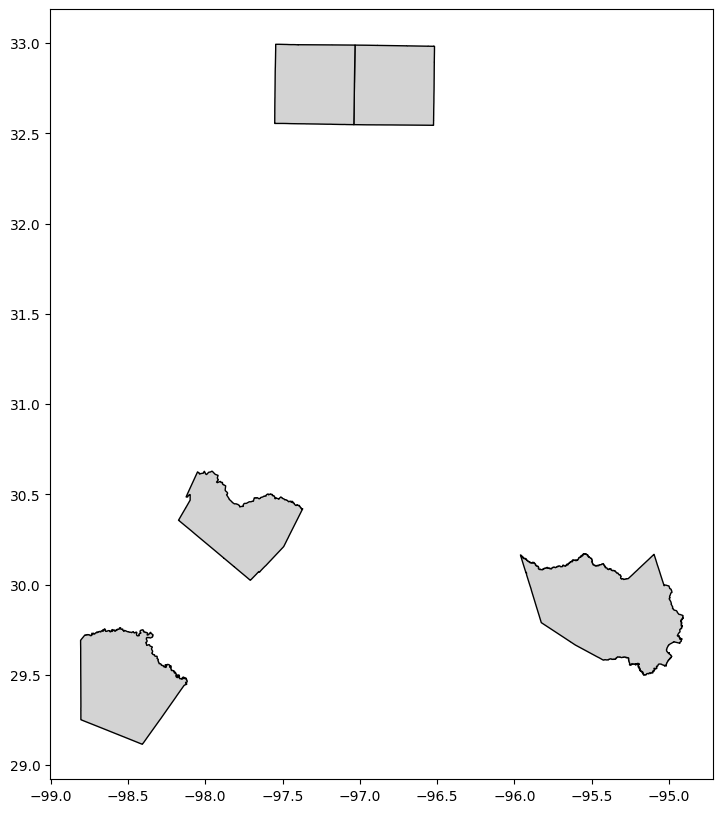

In [16]:
target_counties.plot(edgecolor='black', color='lightgrey', figsize=(10,10)) 
plt.show()

#### There seems to be an issue with the API where I'm only getting 26 CSA farms for the entire state of Texas. I have to download the national data file and read it in. 

In [4]:
# reading in national CSA data file 
raw_points = pd.read_excel('csa_2026-625135642.xlsx')

# converting to GDF 
raw_points_df = gpd.GeoDataFrame(
    raw_points, 
    geometry=gpd.points_from_xy(raw_points['location_x'], raw_points['location_y']),
    crs="EPSG:4326" 
)

# loading desired county boundaries 
target_counties = gpd.read_file('texas_counties.geojson')

# 2. verifying that the CRs matches 
if raw_points_df.crs != target_counties.crs:
    raw_points_df = raw_points_df.to_crs(target_counties.crs)

# removing any rows with empty geometry 
valid_points = raw_points_df[raw_points_df.geometry.is_valid & ~raw_points_df.geometry.is_empty]

# spatial join, using within to drop anything outside of the county polygons 
joined_points_csa = gpd.sjoin(valid_points, target_counties, how="inner", predicate="within")

In [5]:
# Dropping the one duplicate 
joined_points_csa[joined_points_csa['listing_name'] == 'Green Gate Farms']
joined_points_csa = joined_points_csa.drop([413])

In [25]:
joined_points_csa.to_file('usda_csa.gpkg', driver='GPKG')

In [18]:
# reading in national on-farm market data file 
raw_points = pd.read_excel('onfarmmarket_2026-625141939.xlsx')

# converting to GDF 
raw_points_df = gpd.GeoDataFrame(
    raw_points, 
    geometry=gpd.points_from_xy(raw_points['location_x'], raw_points['location_y']),
    crs="EPSG:4326" 
)

# 2. verifying that the CRS matches
if raw_points_df.crs != target_counties.crs:
    raw_points_df = raw_points_df.to_crs(target_counties.crs)

# 3. removing any points with empty geometry 
valid_points = raw_points_df[raw_points_df.geometry.is_valid & ~raw_points_df.geometry.is_empty]

# spatial join, using within to drop anything outside of the county polygons 
joined_points = gpd.sjoin(valid_points, target_counties, how="inner", predicate="within")

In [28]:
joined_points['listing_name'].value_counts()
joined_points.to_file('usda_ofm.gpkg', driver='GPKG')